FERTILITY PREDICTION - KNN & ENSEMBLE MODELS
Loaded 100 samples
Before SMOTE: Normal=70, Altered=10
After SMOTE: Normal=70, Altered=70
Training KNN (k=3)...
Training KNN (k=5)...
Training KNN (k=7)...
Training Random Forest...
Training Gradient Boosting...
Training Voting Ensemble...


KNN (k=3):
   Accuracy: 0.7000
   Precision: 0.2500
   Recall: 1.0000
   F1-Score: 0.4000

KNN (k=5):
   Accuracy: 0.7000
   Precision: 0.2500
   Recall: 1.0000
   F1-Score: 0.4000

KNN (k=7):
   Accuracy: 0.6500
   Precision: 0.2222
   Recall: 1.0000
   F1-Score: 0.3636

Random Forest:
   Accuracy: 0.9000
   Precision: 0.5000
   Recall: 0.5000
   F1-Score: 0.5000

Gradient Boosting:
   Accuracy: 0.9000
   Precision: 0.5000
   Recall: 0.5000
   F1-Score: 0.5000

Voting Ensemble:
   Accuracy: 0.9000
   Precision: 0.5000
   Recall: 0.5000
   F1-Score: 0.5000

🏆 BEST MODEL: Random Forest
   Accuracy: 0.9000
   F1-Score: 0.5000


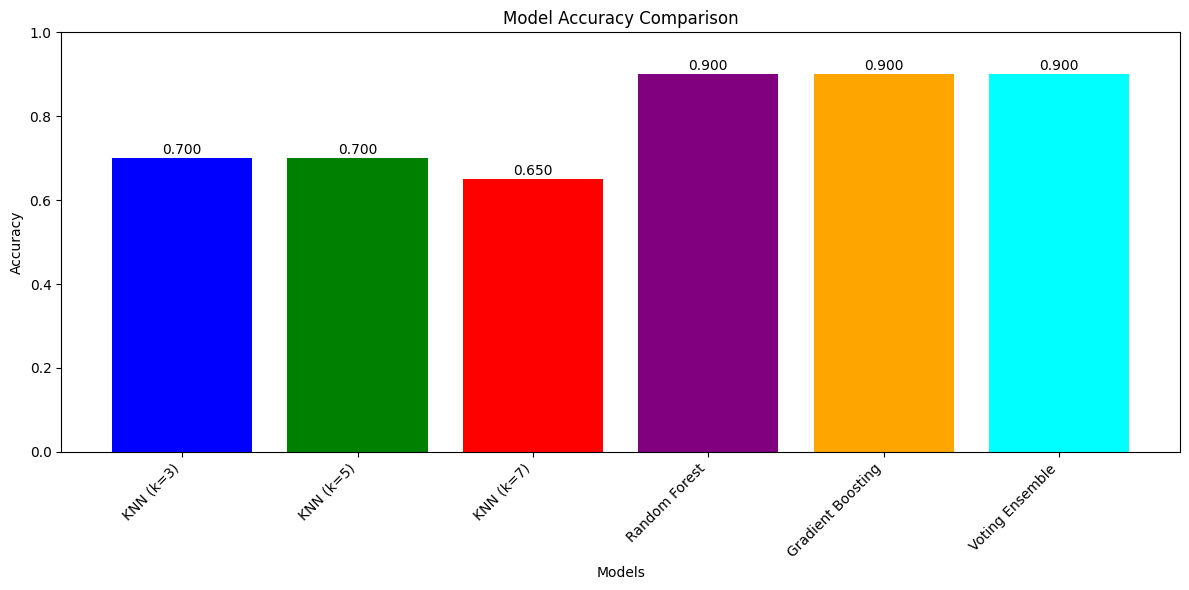

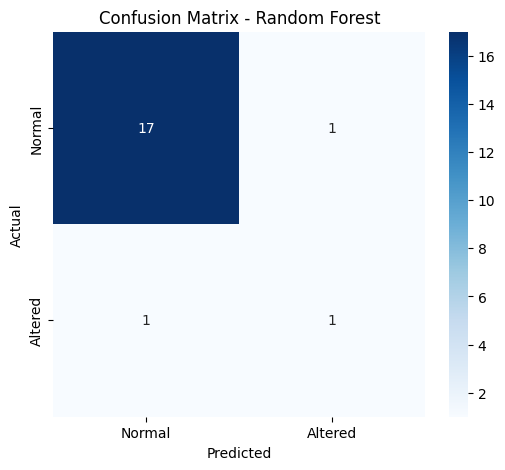

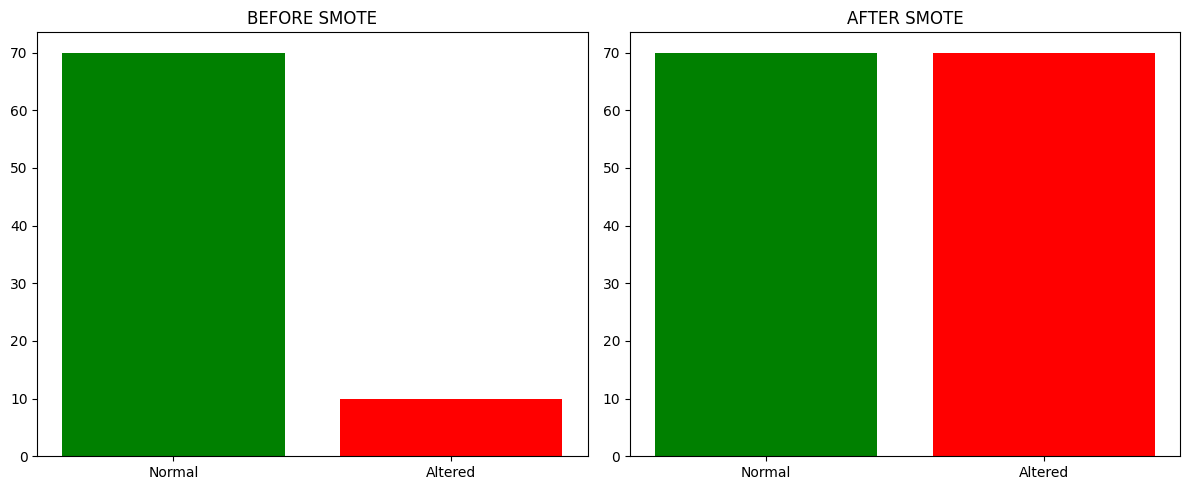


✅ All tasks completed!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE

print("="*60)
print("FERTILITY PREDICTION - KNN & ENSEMBLE MODELS")
print("="*60)

# Load dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00244/fertility_Diagnosis.txt"
column_names = ['Season', 'Age', 'Childish_diseases', 'Accident_trauma',
                'Surgical_intervention', 'High_fever', 'Alcohol_consumption',
                'Smoking_habit', 'Sitting_hours', 'Diagnosis']
df = pd.read_csv(url, names=column_names)
print(f"Loaded {len(df)} samples")

# Preprocess
df['Diagnosis_encoded'] = df['Diagnosis'].map({'N': 0, 'O': 1})
X = df.drop(['Diagnosis', 'Diagnosis_encoded'], axis=1)
y = df['Diagnosis_encoded']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
print(f"Before SMOTE: Normal={sum(y_train==0)}, Altered={sum(y_train==1)}")
print(f"After SMOTE: Normal={sum(y_train_balanced==0)}, Altered={sum(y_train_balanced==1)}")

# Models
models = {
    'KNN (k=3)': KNeighborsClassifier(n_neighbors=3),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'KNN (k=7)': KNeighborsClassifier(n_neighbors=7),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Voting Ensemble': VotingClassifier(estimators=[
        ('knn', KNeighborsClassifier(n_neighbors=5)),
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
        ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42))
    ], voting='hard')
}

results = {}
best_model = None
best_f1 = 0
best_pred = None

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_balanced, y_train_balanced)
    y_pred = model.predict(X_test)

    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0)
    }

    if results[name]['F1-Score'] > best_f1:
        best_f1 = results[name]['F1-Score']
        best_model = name
        best_pred = y_pred

# Display results
print("\n" + "="*60)
for name in results:
    print(f"\n{name}:")
    print(f"   Accuracy: {results[name]['Accuracy']:.4f}")
    print(f"   Precision: {results[name]['Precision']:.4f}")
    print(f"   Recall: {results[name]['Recall']:.4f}")
    print(f"   F1-Score: {results[name]['F1-Score']:.4f}")

print(f"\n🏆 BEST MODEL: {best_model}")
print(f"   Accuracy: {results[best_model]['Accuracy']:.4f}")
print(f"   F1-Score: {results[best_model]['F1-Score']:.4f}")

# Graph 1: Model Comparison
plt.figure(figsize=(12, 6))
names = list(results.keys())
accuracies = [results[n]['Accuracy'] for n in names]
plt.bar(names, accuracies, color=['blue', 'green', 'red', 'purple', 'orange', 'cyan'])
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center')
plt.tight_layout()
plt.show()

# Graph 2: Confusion Matrix
cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Altered'],
            yticklabels=['Normal', 'Altered'])
plt.title(f'Confusion Matrix - {best_model}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Graph 3: SMOTE Comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(['Normal', 'Altered'], [sum(y_train==0), sum(y_train==1)], color=['green', 'red'])
axes[0].set_title('BEFORE SMOTE')
axes[1].bar(['Normal', 'Altered'], [sum(y_train_balanced==0), sum(y_train_balanced==1)], color=['green', 'red'])
axes[1].set_title('AFTER SMOTE')
plt.tight_layout()
plt.show()

print("\n✅ All tasks completed!")